# Ballistic Phonon Transport: Quatrex test



In [1]:
import numpy as np
import phonopy.interface.qe
from numpy.linalg import inv, norm, eigvalsh
import matplotlib.pyplot as plt
import subprocess
import os
import shutil
from pathlib import Path
from scipy.io import savemat

# Physical constants
AMU_KG = 1.66053906660e-27
EV_PER_A2_TO_SI = 1.602176634e-19 / (1e-10) ** 2  # eV/A^2 -> kg/s^2
HBAR_EV = 6.582119569e-16  # eV*s
KB_EV = 8.617333262e-5  # eV/K
THZ_TO_RAD = 2 * np.pi * 1e12  # THz -> rad/s
EV_TO_J = 1.602176634e-19
M_SI_KG = 28.085 * AMU_KG

# Working directory
work_dir = Path(".").resolve()
print(f"Working directory: {work_dir}")

Working directory: /home/paul/Documents/ETH/master/quatrex/phonon/input_calc


## Crystal Structure

Si diamond cubic conventional unit cell: 8 atoms, transport along z.

In [2]:
# a_Si = 5.431  # Angstrom
a_Si = 5.4018 # (paper)

frac_positions = np.array([
    [0.00, 0.00, 0.00],
    [0.50, 0.50, 0.00],
    [0.50, 0.00, 0.50],
    [0.00, 0.50, 0.50],
    [0.25, 0.25, 0.25],
    [0.75, 0.75, 0.25],
    [0.75, 0.25, 0.75],
    [0.25, 0.75, 0.75],
])

lattice_vectors = np.diag([a_Si, a_Si, a_Si])
positions_cart = frac_positions * a_Si
n_atoms = 8
n_dof = 3 * n_atoms

## QE relaxation


In [3]:
def write_qe_input(filename, frac_pos, cell, symbols, ecutwfc=36,
                    kpts=(4, 4, 4), calculation='scf', pseudo_dir='./pseudo'):
    """Write a Quantum ESPRESSO pw.x input file."""
    pseudos = {'Si': 'Si.pbe-n-rrkjus_psl.1.0.0.UPF'}
    masses = {'Si': 28.085}
    unique = list(dict.fromkeys(symbols))

    with open(filename, 'w') as f:
        f.write("&CONTROL\n")
        f.write(f"   calculation      = '{calculation}'\n")
        f.write("   restart_mode     = 'from_scratch'\n")
        f.write("   prefix           = 'phonon_fc'\n")
        f.write(f"   pseudo_dir       = '{pseudo_dir}'\n")
        f.write("   outdir           = './results'\n")
        f.write("   tprnfor          = .true.\n")
        f.write("/\n")
        f.write("&SYSTEM\n")
        f.write("   ibrav            = 0\n")
        f.write(f"   nat              = {len(symbols)}\n")
        f.write(f"   ntyp             = {len(unique)}\n")
        f.write(f"   ecutwfc          = {ecutwfc}\n")
        f.write(f"   ecutrho          = {ecutwfc * 8}\n")
        f.write("   occupations      = 'smearing'\n")
        f.write("   smearing         = 'gaussian'\n")
        f.write("   degauss          = 0.01\n")
        f.write("/\n")
        f.write("&ELECTRONS\n")
        f.write("   conv_thr         = 1e-10\n")
        f.write("/\n")
        if calculation == 'relax':
            f.write("&IONS\n")
            f.write("   ion_dynamics     = 'bfgs'\n")
            f.write("/\n")
            f.write("&CELL\n")
            f.write("/\n")
        f.write("ATOMIC_SPECIES\n")
        for sp in unique:
            f.write(f"  {sp}  {masses[sp]}  {pseudos[sp]}\n")
        f.write("ATOMIC_POSITIONS crystal\n")
        for sym, pos in zip(symbols, frac_pos):
            f.write(f"  {sym}  {pos[0]:.10f}  {pos[1]:.10f}  {pos[2]:.10f}\n")
        f.write("CELL_PARAMETERS angstrom\n")
        for v in cell:
            f.write(f"  {v[0]:.10f}  {v[1]:.10f}  {v[2]:.10f}\n")
        f.write(f"K_POINTS automatic\n")
        f.write(f"  {kpts[0]} {kpts[1]} {kpts[2]}  0 0 0\n")


def read_qe_forces(filename, natoms):
    """Parse forces from QE pw.x output. Returns (natoms, 3) in eV/Ang."""
    RY_BOHR_TO_EV_ANG = 25.71104309541616
    with open(filename) as f:
        text = f.read()
    if 'JOB DONE' not in text:
        raise RuntimeError(f"QE did not converge: {filename}")
    forces = []
    for line in text.split('Forces acting on atoms')[-1].split('\n'):
        if 'force =' in line:
            vals = line.split('force =')[1].split()
            forces.append([float(v) for v in vals[:3]])
        if len(forces) == natoms:
            break
    if len(forces) != natoms:
        raise ValueError(f"Expected {natoms} forces, got {len(forces)}")
    return np.array(forces) * RY_BOHR_TO_EV_ANG

In [5]:
# Relaxation
relax_dir = work_dir / 'relax'
relax_out = relax_dir / 'relax.out'

relax_dir.mkdir(exist_ok=True)
(relax_dir / 'results').mkdir(exist_ok=True)
if not (relax_dir / 'pseudo').exists():
    os.symlink(work_dir / 'pseudo', relax_dir / 'pseudo')

write_qe_input(
    relax_dir / 'relax.in', frac_positions, lattice_vectors,
    ['Si'] * 8, ecutwfc=60, kpts=(8, 8, 8), calculation='relax',
)
print("Running QE relaxation")
result = subprocess.run(
    'pw.x < relax.in > relax.out 2>&1',
    shell=True, cwd=relax_dir,
)
print(f"  exit code: {result.returncode}")


Running QE relaxation


KeyboardInterrupt: 

## Force Constants from Phonopy


In [4]:
from phonopy import Phonopy
from phonopy.structure.atoms import PhonopyAtoms

ph_cell = PhonopyAtoms(
    symbols=['Si'] * 8,
    cell=lattice_vectors,
    scaled_positions=frac_positions,
)
phonon = Phonopy(
    ph_cell,
    supercell_matrix=np.diag([2, 2, 2]),
    primitive_matrix=np.eye(3),
)
phonon.generate_displacements(distance=0.01)

n_disp = len(phonon.displacements)
n_super = len(phonon.supercell.positions)
print(f"Supercell: {n_super} atoms")
print(f"Displacements: {n_disp}")

Supercell: 64 atoms
Displacements: 1


In [7]:
scf_dir = work_dir / 'scf_disp'
scf_dir.mkdir(exist_ok=True)
(scf_dir / 'results').mkdir(exist_ok=True)
if not (scf_dir / 'pseudo').exists():
    os.symlink(work_dir / 'pseudo', scf_dir / 'pseudo')

force_sets = []
all_done = True

for i, sc in enumerate(phonon.supercells_with_displacements):
    tag = f'disp-{i+1:03d}'
    in_file = scf_dir / f'{tag}.in'
    out_file = scf_dir / f'{tag}.out'

    # Write input
    write_qe_input(
        in_file, sc.scaled_positions, sc.cell,
        ['Si'] * n_super, ecutwfc=36, kpts=(2, 2, 2),
        pseudo_dir='./pseudo',
    )

    # Run if output doesn't exist
    if not out_file.exists():
        print(f"  Running {tag}...", flush=True)
        subprocess.run(
            f'pw.x < {tag}.in > {tag}.out 2>&1',
            shell=True, cwd=scf_dir,
        )

    # Parse forces
    try:
        forces = read_qe_forces(out_file, n_super)
        force_sets.append(forces)
        print(f"  {tag}: max |F| = {np.max(np.abs(forces)):.6f} eV/A")
    except Exception as e:
        print(f"  {tag}: FAILED -- {e}")
        all_done = False

if not all_done:
    raise RuntimeError("Not all SCF calculations completed successfully.")
print(f"\nAll {n_disp} displacements done.")

  disp-001: max |F| = 0.134330 eV/A

All 1 displacements done.


In [8]:
import phonopy.interface.qe

In [14]:
phonon.forces = phonopy.interface.qe.parse_set_of_forces(64, ['scf_disp/supercell-001.out'])

1. Drift force of "scf_disp/supercell-001.out" to be subtracted
 -0.00000000   0.00000000   0.00000000


In [15]:
# Compute force constants


#phonon.forces = np.array(force_sets)
phonon.produce_force_constants()

fc = phonon.force_constants
print(f"Force constants shape: {fc.shape}") # fc[prim_atom, super_atom, 3, 3]

Force constants shape: (64, 64, 3, 3)


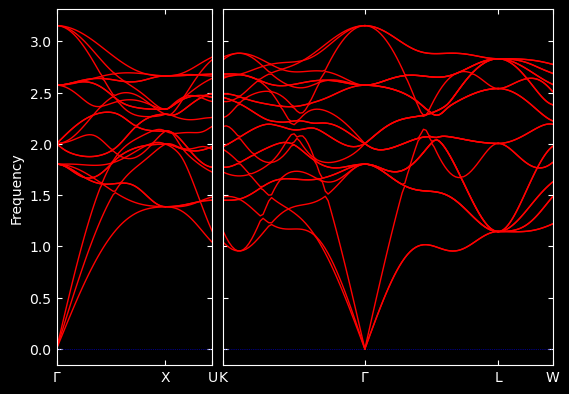

In [21]:
from phonopy.phonon.band_structure import get_band_qpoints_and_path_connections

path = [[[0, 0, 0], [0.5, 0, 0.5], [0.625, 0.25, 0.625]],
        [[0.375, 0.375, 0.75], [0, 0, 0], [0.5, 0.5, 0.5], [0.5, 0.25, 0.75]]]
labels = ["$\\Gamma$", "X", "U", "K", "$\\Gamma$", "L", "W"]
qpoints, connections = get_band_qpoints_and_path_connections(path, npoints=51)

phonon.run_band_structure(qpoints, path_connections=connections, labels=labels)
phonon.plot_band_structure().show()

Split into K_00 (nz=0, on-site), K_01 (nz=+1, forward coupling), K_m1 (nz=-1, backward coupling),
each indexed by transverse offset (nx, ny).

In [16]:
def extract_k_blocks(phonon, fc):
    """Extract NEGF block-tridiagonal FC from phonopy force constants.

    Returns dict: (nz, nx, ny) -> (24, 24) ndarray [eV/Ang^2].
    """
    sc_pos = phonon.supercell.positions
    prim_pos = phonon.primitive.positions
    inv_cell = np.linalg.inv(phonon.primitive.cell)
    L_sc = np.diag(phonon.supercell.cell)
    n_prim = len(prim_pos)
    n_super = len(sc_pos)
    n_dof = 3 * n_prim

    # Map supercell atoms to primitive atom indices
    indices = np.zeros(n_super, dtype=int)
    for s in range(n_super):
        best = (1e10, 0)
        for p in range(n_prim):
            R = (sc_pos[s] - prim_pos[p]) @ inv_cell
            err = np.linalg.norm(R - np.round(R))
            if err < best[0]:
                best = (err, p)
        indices[s] = best[1]

    K = {}
    for s in range(n_super):
        j = indices[s]
        for p in range(n_prim):
            d = sc_pos[s] - prim_pos[p]
            d_min = d - np.round(d / L_sc) * L_sc
            intra = prim_pos[j] - prim_pos[p]
            phys = np.round((d_min - intra) @ inv_cell).astype(int)
            key = (int(phys[2]), int(phys[0]), int(phys[1]))  # (nz, nx, ny)
            if key not in K:
                K[key] = np.zeros((n_dof, n_dof))
            K[key][3 * p : 3 * p + 3, 3 * j : 3 * j + 3] += fc[p, s]

    # Symmetrize: K(R) = K(-R)^T
    done = set()
    for key in list(K):
        if key in done:
            continue
        neg = tuple(-k for k in key)
        if neg == key:
            K[key] = 0.5 * (K[key] + K[key].T)
        elif neg in K:
            avg = 0.5 * (K[key] + K[neg].T)
            K[key] = avg
            K[neg] = avg.T
        done.update([key, neg])

    # Acoustic sum rule: diagonal of K(0,0,0) so each row-block sums to zero
    K_self = np.zeros((n_dof, n_dof))
    for key, block in K.items():
        for i in range(n_prim):
            for j in range(n_prim):
                if not (key == (0, 0, 0) and i == j):
                    K_self[3 * i : 3 * i + 3, 3 * i : 3 * i + 3] -= block[
                        3 * i : 3 * i + 3, 3 * j : 3 * j + 3
                    ]
    K[(0, 0, 0)] = K_self

    return K


def split_fc_by_z(K_blocks):
    """Split FC dict by transport (z) slab index."""
    K_00, K_01, K_m1 = {}, {}, {}
    for (nz, nx, ny), K in K_blocks.items():
        if nz == 0:
            K_00[(nx, ny)] = K
        elif nz == 1:
            K_01[(nx, ny)] = K
        elif nz == -1:
            K_m1[(nx, ny)] = K
    return K_00, K_01, K_m1


K_blocks = extract_k_blocks(phonon, fc)
K_00, K_01, K_m1 = split_fc_by_z(K_blocks)

print(f"FC blocks: {len(K_blocks)} total")
print(f"  K_00 (nz=0):  {sorted(K_00.keys())}")
print(f"  K_01 (nz=+1): {sorted(K_01.keys())}")
print(f"  K_m1 (nz=-1): {sorted(K_m1.keys())}")

FC blocks: 27 total
  K_00 (nz=0):  [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 0), (0, 1), (1, -1), (1, 0), (1, 1)]
  K_01 (nz=+1): [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 0), (0, 1), (1, -1), (1, 0), (1, 1)]
  K_m1 (nz=-1): [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 0), (0, 1), (1, -1), (1, 0), (1, 1)]


In [29]:
# # Gamma-point validation
# def build_dyn_matrix_q(K_00, K_01, K_m1, q_perp, a, mass_kg):
#     """Build Fourier-transformed dynamical matrix blocks at q_perp."""
#     fac = EV_PER_A2_TO_SI / mass_kg
#     D_00 = sum(
#         K * np.exp(1j * q_perp @ np.array([nx * a, ny * a]))
#         for (nx, ny), K in K_00.items()
#     ) * fac
#     D_01 = sum(
#         K * np.exp(1j * q_perp @ np.array([nx * a, ny * a]))
#         for (nx, ny), K in K_01.items()
#     ) * fac
#     D_m1 = sum(
#         K * np.exp(1j * q_perp @ np.array([nx * a, ny * a]))
#         for (nx, ny), K in K_m1.items()
#     ) * fac
#     return D_00, D_01, D_m1
#
#
# D00, D01, Dm1 = build_dyn_matrix_q(
#     K_00, K_01, K_m1, np.array([0.0, 0.0]), a_Si, M_SI_KG
# )
# D_gamma = D00 + D01 + Dm1

mesh = [20, 20, 20]
phonon.run_mesh(mesh)
mesh_dict = phonon.get_mesh_dict()

D_gamma = phonon.dynamical_matrix.dynamical_matrix

eigs = eigvalsh(D_gamma.real)
freqs_gamma = np.sign(eigs) * np.sqrt(np.abs(eigs)) #/ THZ_TO_RAD


print(f"Phonon frequencies at Gamma (THz):")
print(f"  {np.sort(freqs_gamma).round(2)}")
print(f"  3 acoustic modes near 0: {np.sort(np.abs(freqs_gamma))[:3].round(4)}")

print(f"  max|D_00 - D_00^H| = {np.max(np.abs(D00 - D00.conj().T)):.2e}")
print(f"  max|D_01^H - D_m1| = {np.max(np.abs(D01.conj().T - Dm1)):.2e}")

Phonon frequencies at Gamma (THz):
  [0.09 0.1  0.11 0.12 0.12 0.12 0.12 0.13 0.13 0.13 0.14 0.14 0.14 0.14
 0.15 0.15 0.15 0.16 0.16 0.16 0.16 0.16 0.17 0.17]
  3 acoustic modes near 0: [0.0868 0.1023 0.1137]
  max|D_00 - D_00^H| = 5.15e+10
  max|D_01^H - D_m1| = 4.29e+09


In [ ]:
phonon.dynamical_matrix

## quatrex Inputs

- `dynamical_matrix.mat` -- mass-normalized FC in (rad/s)^2 units
- `structure.xyz` -- extended XYZ with lattice vectors
- `quatrex_config.toml` -- simulation configuration

In [15]:
quatrex_dir = work_dir / 'quatrex_inputs'
quatrex_dir.mkdir(exist_ok=True)

num_transport_cells = 4
nq = 4  # transverse q-mesh (4x4)

# --- dynamical_matrix.mat ---
# Keys: [nx, ny, nz], values: (24, 24) in (rad/s)^2
fac = EV_PER_A2_TO_SI / M_SI_KG
mat_dict = {}
for (nz, nx, ny), K in K_blocks.items():
    key = f"[{nx}, {ny}, {nz}]"
    mat_dict[key] = K * fac

savemat(str(quatrex_dir / 'dynamical_matrix.mat'), mat_dict)
print(f"Saved dynamical_matrix.mat ({len(mat_dict)} blocks, (rad/s)^2 units)")

# --- structure.xyz ---
with open(quatrex_dir / 'structure.xyz', 'w') as f:
    f.write(f"{n_atoms}\n")
    lv = lattice_vectors
    f.write(
        f'Lattice="{lv[0,0]} {lv[0,1]} {lv[0,2]} '
        f'{lv[1,0]} {lv[1,1]} {lv[1,2]} '
        f'{lv[2,0]} {lv[2,1]} {lv[2,2]}" '
        f'Properties=species:S:1:pos:R:3 pbc="T T T"\n'
    )
    for pos in positions_cart:
        f.write(f"Si  {pos[0]:.8f}  {pos[1]:.8f}  {pos[2]:.8f}\n")
print(f"Saved structure.xyz ({n_atoms} atoms)")

# --- quatrex_config.toml ---
config_text = f"""simulation_dir = "."
input_dir = "."

formalism = "negf"
simulation_type = "phonon"

[device]
transport_direction = 'z'
construct_from_unit_cell = true
num_transport_cells = {num_transport_cells}
neighbor_cell_cutoff = [1, 1, 1]
kpoint_grid = [{nq}, {nq}, 1]
kpoint_shift = [0.0, 0.0, 0.0]

[device.num_orbitals_per_atom]
Si = 3

[scba]
max_iterations = 1
phonon = true

[electron]
energy_window_min = -1.0
energy_window_max = 1.0
energy_window_num = 10
fermi_level = 0.0
conduction_band_edge = 0.5
valence_band_edge = -0.5
left_fermi_level = 0.0
right_fermi_level = 0.0

[phonon]
eta = 1e-8
eta_obc = 0.0
left_temperature = 301.0
right_temperature = 299.0
model = "negf"
phonon_energy = 0.063
deformation_potential = 1.0

[phonon.solver]
compute_current = true

[phonon.obc]
algorithm = "sancho-rubio"
block_sections = 1
"""
with open(quatrex_dir / 'quatrex_config.toml', 'w') as f:
    f.write(config_text)
print(f"Saved quatrex_config.toml")
print(f"  transport cells: {num_transport_cells}, q-mesh: {nq}x{nq}")

Saved dynamical_matrix.mat (27 blocks, (rad/s)^2 units)
Saved structure.xyz (8 atoms)
Saved quatrex_config.toml
  transport cells: 4, q-mesh: 4x4


##  Run ballistic PhononSolver


In [18]:
import sys
import warnings

sys.path.insert(0, str(Path(work_dir).parents[1] / 'src'))
warnings.filterwarnings('ignore')

from qttools import xp, sparse
from qttools.comm import comm
from qttools.utils.mpi_utils import get_local_slice
from quatrex.core.config import parse_config
from quatrex.core.statistics import bose_einstein
from quatrex.phonon.solver import PhononSolver
from quatrex.device.inputs import load_matrix

In [22]:
os.chdir(quatrex_dir)

# Frequency grid
n_freq = 201
freqs_thz = np.linspace(0.01, 16.0, n_freq)
omega_rad = freqs_thz * THZ_TO_RAD
omega_sq = omega_rad**2

# Config
config = parse_config('quatrex_config.toml')
config.phonon.eta = 1e20  # (rad/s)^2 broadening

# Load dynamical matrix to get sparsity pattern
dm_temp, sp = load_matrix(
    config=config, matrix_name='dynamical_matrix',
    sparsity_pattern=None, shift_kpoints=False,
)
sparsity_pattern = sp.copy()
del dm_temp

# Create solver
solver = PhononSolver(config, omega_sq, sparsity_pattern)

local_freqs = get_local_slice(omega_sq, comm.stack)
local_omega_rad = np.sqrt(np.abs(local_freqs))
hbar_omega_eV = HBAR_EV * local_omega_rad
T_L, T_R = 301.0, 299.0
solver.left_occupancies = bose_einstein(hbar_omega_eV, T_L)
solver.right_occupancies = bose_einstein(hbar_omega_eV, T_R)
solver.left_temperature = T_L
solver.right_temperature = T_R

print(f"Solver ready: {n_freq} freqs, {nq}x{nq} q-mesh")
print(f"  block sizes: {solver.block_sizes}")
print(f"  eta = {config.phonon.eta:.0e}")

Solver ready: 201 freqs, 4x4 q-mesh
  block sizes: [24 24 24 24]
  eta = 1e+20


In [23]:
# Allocate Green's functions and zero self-energies (ballistic)
DSDB = type(solver.dynamical_matrix)
stack_shape = omega_sq.shape + tuple(
    [int(k) for k in config.device.kpoint_grid if k > 1]
)

g_lesser = DSDB.from_sparray(
    sp.astype(xp.complex128),
    block_sizes=solver.block_sizes,
    global_stack_shape=stack_shape,
)
g_greater = DSDB.zeros_like(g_lesser)
g_retarded = DSDB.zeros_like(g_lesser)
sse_lesser = DSDB.zeros_like(g_lesser)
sse_greater = DSDB.zeros_like(g_lesser)
sse_retarded = DSDB.zeros_like(g_lesser)

out = (g_lesser, g_greater, g_retarded)

print("Solving...")
solver.solve(sse_lesser, sse_greater, sse_retarded, out)
print("Done.")

Solving...
Done.


In [24]:
# Extract transmission from Meir-Wingreen current
current = solver.meir_wingreen_current  # (n_freq, kx, ky, n_blocks-1)
dn = solver.left_occupancies - solver.right_occupancies
n_kpoints = nq * nq

# Sum spectral current over k-points (first block interface)
spectral_current = current[:, :, :, 0].real
total_current = np.sum(spectral_current, axis=(1, 2))

# T(omega) = I(omega) / (n_L - n_R) / N_k
mask = np.abs(dn) > 1e-20
trans_quatrex = np.zeros(n_freq)
trans_quatrex[mask] = total_current[mask] / dn[mask] / n_kpoints

# Current conservation check
n_interfaces = current.shape[-1]
for i in range(n_interfaces):
    ci = np.sum(current[:, :, :, i].real, axis=(1, 2))
    print(f"Interface {i}: max |I| = {np.max(np.abs(ci)):.4e}")

print(f"\nMax transmission: {trans_quatrex.max():.4f}")

Interface 0: max |I| = 3.3338e+01
Interface 1: max |I| = 3.3338e+01
Interface 2: max |I| = 3.3338e+01

Max transmission: 2.6249


##  Reference

In [25]:
def sancho_rubio(omega_sq, phi_00, phi_01, eta=1e-4, max_iter=300, tol=1e-8):
    """Surface Green's function via Sancho-Rubio decimation."""
    N = phi_00.shape[0]
    phi_10 = phi_01.conj().T

    a_ii = (omega_sq + 1j * eta) * np.eye(N) - phi_00
    a_ij = -phi_01
    a_ji = -phi_10

    eps = a_ii.copy()
    eps_s = a_ii.copy()
    alpha = a_ji.copy()
    beta = a_ij.copy()

    for _ in range(max_iter):
        inv_eps = inv(eps)
        eps_s -= alpha @ inv_eps @ beta
        eps -= alpha @ inv_eps @ beta + beta @ inv_eps @ alpha
        alpha_new = alpha @ inv_eps @ alpha
        beta_new = beta @ inv_eps @ beta
        alpha, beta = alpha_new, beta_new
        if norm(alpha) + norm(beta) < tol:
            break

    return inv(eps_s)


def ballistic_transmission(omega_sq, phi_D, phi_L00, phi_L01,
                           phi_R00, phi_R01, phi_LD, phi_DR, eta=1e-4):
    """Ballistic transmission via Caroli: T = Tr(Gamma_L G^R Gamma_R G^A)."""
    N_D = phi_D.shape[0]

    g_L = sancho_rubio(omega_sq, phi_L00, phi_L01, eta)
    g_R = sancho_rubio(omega_sq, phi_R00, phi_R01.conj().T, eta)

    Sigma_L = phi_LD.conj().T @ g_L @ phi_LD
    Sigma_R = phi_DR @ g_R @ phi_DR.conj().T

    Gamma_L = 1j * (Sigma_L - Sigma_L.conj().T)
    Gamma_R = 1j * (Sigma_R - Sigma_R.conj().T)

    G_R = inv((omega_sq + 1j * eta) * np.eye(N_D) - phi_D - Sigma_L - Sigma_R)
    G_A = G_R.conj().T

    T = np.real(np.trace(Gamma_L @ G_R @ Gamma_R @ G_A))
    return max(T, 0.0)


def thermal_conductance(freqs_thz, transmission, T_kelvin, a_lat):
    """Ballistic thermal conductance per unit area [W/(m^2 K)]."""
    omegas = freqs_thz * THZ_TO_RAD
    hw = HBAR_EV * omegas
    x = hw / (KB_EV * T_kelvin)

    dfdt = np.zeros_like(x)
    valid = (x > 1e-10) & (x < 500)
    dfdt[valid] = (hw[valid] / (KB_EV * T_kelvin**2)) * (
        np.exp(x[valid]) / (np.exp(x[valid]) - 1) ** 2
    )

    dw = (freqs_thz[1] - freqs_thz[0]) * THZ_TO_RAD
    integrand = transmission * hw * dfdt * dw / (2 * np.pi)
    A_c = (a_lat * 1e-10) ** 2
    return np.sum(integrand) * EV_TO_J / A_c

In [26]:
# Compute reference ballistic transmission for pure Si
q_1d = np.array(
    [(2 * n - nq - 1) / (2 * nq) for n in range(1, nq + 1)]
) * 2 * np.pi / a_Si
qx, qy = np.meshgrid(q_1d, q_1d)
q_points = np.stack([qx.ravel(), qy.ravel()], axis=-1)

freqs_ref = np.linspace(0.01, 16.0, n_freq)
omega_sqs_ref = (freqs_ref * THZ_TO_RAD) ** 2
dw_ref = (freqs_ref[1] - freqs_ref[0]) * THZ_TO_RAD
eta_ref = dw_ref**2 * 0.5

trans_ref = np.zeros(n_freq)
print(f"Reference: {n_freq} freqs x {len(q_points)} q-points")

for iq, q in enumerate(q_points):
    D00, D01, Dm1 = build_dyn_matrix_q(K_00, K_01, K_m1, q, a_Si, M_SI_KG)
    for iw, w2 in enumerate(omega_sqs_ref):
        trans_ref[iw] += ballistic_transmission(
            w2, D00, D00, D01, D00, D01, D01, D01, eta=eta_ref,
        )

trans_ref /= len(q_points)
print(f"Max reference transmission: {trans_ref.max():.4f}")

Reference: 201 freqs x 16 q-points
Max reference transmission: 2.5496


 Comparison

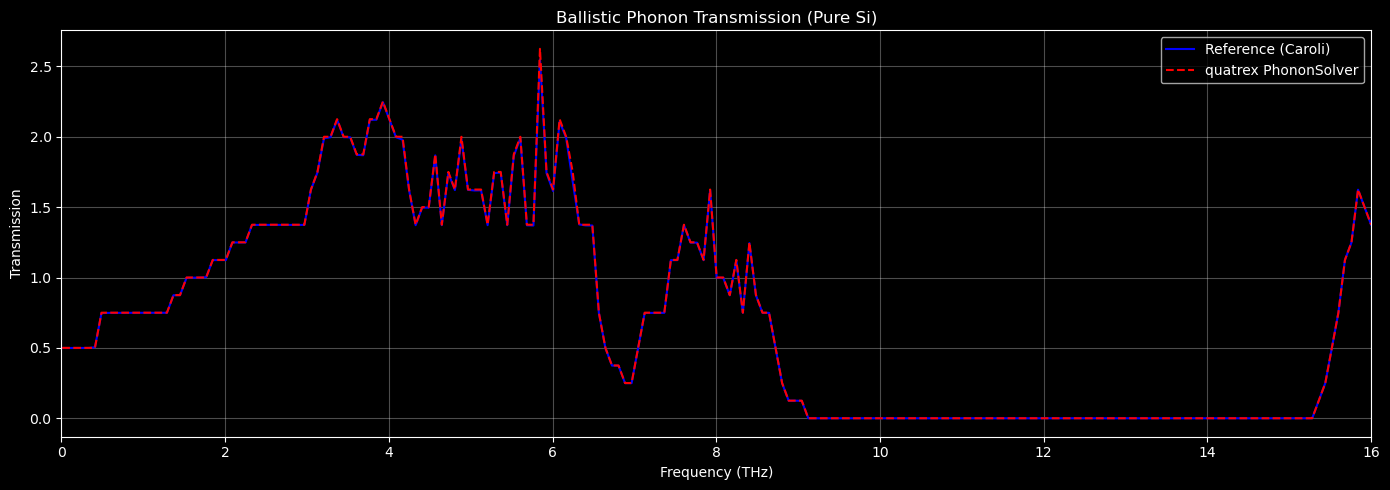

In [31]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# --- Transmission ---
ax = axes
ax.plot(freqs_ref, trans_ref, 'b-', lw=1.5, label='Reference (Caroli)')
ax.plot(freqs_thz, trans_quatrex, 'r--', lw=1.5, label='quatrex PhononSolver')
ax.set_xlabel('Frequency (THz)')
ax.set_ylabel('Transmission')
ax.set_title('Ballistic Phonon Transmission (Pure Si)')
ax.set_xlim(0, 16)
ax.legend()
ax.grid(True, alpha=0.3)

# # --- Thermal conductance integrand ---
# ax = axes[1]
# T_kelvin = 300.0
# hw = HBAR_EV * freqs_ref * THZ_TO_RAD
# x = hw / (KB_EV * T_kelvin)
# dfdt = np.zeros_like(x)
# valid = (x > 1e-10) & (x < 500)
# dfdt[valid] = (hw[valid] / (KB_EV * T_kelvin**2)) * (
#     np.exp(x[valid]) / (np.exp(x[valid]) - 1) ** 2
# )
#
# weight = hw * dfdt  # proportional to contribution per mode
# ax.plot(freqs_ref, trans_ref * weight, 'b-', lw=1.5, label='Reference')
# ax.plot(freqs_thz, trans_quatrex * weight, 'r--', lw=1.5, label='quatrex')
# ax.set_xlabel('Frequency (THz)')
# ax.set_ylabel(r'$\mathcal{T} \cdot \hbar\omega \cdot \partial f / \partial T$')
# ax.set_title('Conductance Integrand')
# ax.set_xlim(0, 16)
# ax.legend()
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
G_ref = thermal_conductance(freqs_ref, trans_ref, T_kelvin, a_Si)
G_quatrex = thermal_conductance(freqs_thz, trans_quatrex, T_kelvin, a_Si)

print(f"Thermal conductance @ {T_kelvin} K")
print(f"  Reference:      {G_ref / 1e6:.1f}")
print(f"  quatrex PhononSolver:    {G_quatrex / 1e6:.1f}")

Thermal conductance @ 300.0 K
  Reference:      517.6
  quatrex PhononSolver:    519.3


In [ ]:
os.chdir(work_dir)

K_00_keys = sorted(K_00.keys())
K_01_keys = sorted(K_01.keys())
K_m1_keys = sorted(K_m1.keys())

np.savez(
    'si_force_constants.npz',
    K_00=np.array([K_00[k] for k in K_00_keys]),
    K_00_offsets=np.array(K_00_keys),
    K_01=np.array([K_01[k] for k in K_01_keys]),
    K_01_offsets=np.array(K_01_keys),
    K_m1=np.array([K_m1[k] for k in K_m1_keys]),
    K_m1_offsets=np.array(K_m1_keys),
    atom_positions=positions_cart,
    lattice_constant=a_Si,
)
